# DATA 6400 — Qwen2.5-7B Zero-Shot Fake Review Detection


### What this notebook does
1. Installs dependencies and loads the **DiFraud** `product_reviews` dataset
2. Replicates the exact **length grouping** from your main notebook (short ≤ 42 tok, medium 43–71, long > 71)
3. Loads **Qwen2.5-7B-Instruct** in **4-bit** (fits on a T4 GPU)
4. Tests **5 different prompt formulations** — zero-shot binary classification (Fake=1, Real=0)
5. Evaluates **accuracy, precision, recall, F1** — overall and per length group
6. Computes **prompt disagreement** across all 5 prompts
7. Saves all results to `/content/` (and optionally Google Drive)

> ⚠️ **Make sure GPU is enabled**: Runtime → Change runtime type → T4 GPU

## 1. Install Dependencies

In [ ]:
!pip -q uninstall -y datasets
!pip -q install datasets==2.18.0
!pip -q install -U "numpy<2.0" "pandas<2.3" transformers accelerate bitsandbytes sentencepiece scikit-learn matplotlib tqdm
print("All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 19.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━

## 2. Imports & GPU Check

In [ ]:
import os
import gc
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import datasets

from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print("datasets version:", datasets.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("No GPU found. Enable T4 via Runtime → Change runtime type.")

datasets version: 2.18.0
CUDA available: True
GPU: Tesla T4


## 3. Load DiFraud Dataset

In [ ]:
ds = load_dataset("difraud/difraud", "product_reviews", trust_remote_code=True)
print(ds)
print("\nColumns:", ds["train"].column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16776
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2097
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2098
    })
})

Columns: ['text', 'label']


## 4. Data Quality Check

In [ ]:
train_df = pd.DataFrame(ds["train"])
test_df  = pd.DataFrame(ds["test"])

print("=== Train null check ===")
print(train_df.isnull().sum())

print("\n=== Class balance (train) ===")
print(train_df["label"].value_counts())
print(train_df["label"].value_counts(normalize=True))

print("\n=== Test set shape ===")
print(test_df.shape)
print(test_df["label"].value_counts())

=== Train null check ===
text     0
label    0
dtype: int64

=== Class balance (train) ===
label
1    8393
0    8383
Name: count, dtype: int64
label
1    0.500298
0    0.499702
Name: proportion, dtype: float64

=== Test set shape ===
(2098, 2)
label
1    1050
0    1048
Name: count, dtype: int64


## 5. Length Analysis & Group Assignment
Replicates **exactly** the tokenisation and quantile thresholds from your main notebook.
- Short  : ≤ 42 tokens
- Medium : 43–71 tokens  
- Long   : > 71 tokens

In [ ]:
# Use the RoBERTa tokenizer — same as main notebook
roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def count_tokens(example):
    tokens = roberta_tokenizer.tokenize(example["text"])
    example["n_tokens"] = len(tokens) + 2   # +2 for [CLS] and [SEP]
    return example

ds = ds.map(count_tokens)

# Compute quantile thresholds from the TRAIN split only
train_lengths = ds["train"]["n_tokens"]
Q1 = np.quantile(train_lengths, 0.33)
Q2 = np.quantile(train_lengths, 0.66)
print(f"Quantile thresholds — Q1 (33rd): {Q1}  |  Q2 (66th): {Q2}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16776 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (593 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/2097 [00:00<?, ? examples/s]

Map:   0%|          | 0/2098 [00:00<?, ? examples/s]

Quantile thresholds — Q1 (33rd): 42.0  |  Q2 (66th): 71.0


In [ ]:
def assign_length_group(example):
    if example["n_tokens"] <= Q1:
        example["length_group"] = "short"
    elif example["n_tokens"] <= Q2:
        example["length_group"] = "medium"
    else:
        example["length_group"] = "long"
    return example

ds = ds.map(assign_length_group)

print("Train :", Counter(ds["train"]["length_group"]))
print("Val   :", Counter(ds["validation"]["length_group"]))
print("Test  :", Counter(ds["test"]["length_group"]))

Map:   0%|          | 0/16776 [00:00<?, ? examples/s]

Map:   0%|          | 0/2097 [00:00<?, ? examples/s]

Map:   0%|          | 0/2098 [00:00<?, ? examples/s]

Train : Counter({'long': 5666, 'short': 5622, 'medium': 5488})
Val   : Counter({'long': 731, 'medium': 696, 'short': 670})
Test  : Counter({'long': 722, 'short': 699, 'medium': 677})


In [ ]:
# Build final test DataFrame for Qwen evaluation
test_qwen = pd.DataFrame(ds["test"])   # columns: text, label, n_tokens, length_group
print("Test DataFrame shape:", test_qwen.shape)
test_qwen.head(3)

Test DataFrame shape: (2098, 4)


,text,label,n_tokens,length_group
0,I bought this at a local mart store for under ...,0,148,long
1,So bad experience. Got defected unit and they ...,1,73,long
2,Update 11/28/2015 - Almost 2 years later and t...,0,140,long


## 6. Load Qwen2.5-7B-Instruct (4-bit quantised)

In [ ]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

QWEN_MODEL = "Qwen/Qwen2.5-7B-Instruct"

quant_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,  # nested quant saves extra VRAM
)

print(f"Loading tokenizer: {QWEN_MODEL}")
qwen_tok = AutoTokenizer.from_pretrained(QWEN_MODEL)
if qwen_tok.pad_token is None:
    qwen_tok.pad_token = qwen_tok.eos_token

print(f"Loading model (4-bit NF4): {QWEN_MODEL}")
qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL,
    quantization_config=quant_cfg,
    device_map="auto",
    low_cpu_mem_usage=True,
)
qwen_model.eval()
print("\n✓ Model loaded successfully.")

Loading tokenizer: Qwen/Qwen2.5-7B-Instruct


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]


✓ Model loaded successfully.


## 7. Prompt Definitions
Five prompts that frame the same binary FAKE / REAL task with increasing richness of guidance.

| Prompt | Strategy |
|--------|----------|
| A | Minimal / direct — no guidance (pure zero-shot baseline) |
| B | Cue-rich — enumerates concrete linguistic signals |
| C | Contrastive framing — defines REAL vs FAKE side-by-side |
| D | Role-based — casts Qwen as a fraud detection expert |
| E | Reasoning-first — brief think-step before label |

In [ ]:
SYSTEM_MSG = (
    "You are an expert classifier for fake product reviews. "
    "You may think internally, but your final response must end with exactly one line in this format: "
    "FINAL_LABEL: FAKE or FINAL_LABEL: REAL. "
    "Do not end with anything else after that final line."
)




PROMPT_A = """Classify this product review as FAKE or REAL.

A REAL review usually reflects genuine product experience, including concrete details, natural wording, or personal usage.
A FAKE review often relies on vague praise, exaggerated enthusiasm, or promotional language without clear evidence of real use.

Output exactly one word:
FAKE
or
REAL

Review:
{review}
"""

PROMPT_B = """Classify this product review as FAKE or REAL.

Consider whether it reflects genuine product experience or vague promotional language.

Output exactly one word:
FAKE
or
REAL

Review:
{review}
"""

PROMPT_C = """Classify this product review as FAKE or REAL.

Use cues such as specific experience, vague praise, and promotional wording.

Output exactly one word:
FAKE
or
REAL

Review:
{review}
"""


PROMPT_D = """You are a fraud detection expert specialised in e-commerce review authenticity.

Classify the review as FAKE or REAL.

Output exactly one word:
FAKE
or
REAL

Review:
{review}
"""

PROMPT_E = """Read the product review below and decide whether it sounds genuine or fabricated.

Return your final decision on the last line exactly as:
FINAL_LABEL: FAKE
or
FINAL_LABEL: REAL

Review:
{review}
"""

PROMPTS = {
    "prompt_A": PROMPT_A,
    "prompt_B": PROMPT_B,
    "prompt_C": PROMPT_C,
    "prompt_D": PROMPT_D,
    "prompt_E": PROMPT_E,
}

print(f"✓ {len(PROMPTS)} prompts defined.")

✓ 5 prompts defined.


## 8. Inference Utilities

In [ ]:
def parse_output(text: str):
    """
    Extract a binary label from the model's raw output.
    Returns: 1 (FAKE), 0 (REAL), or None if unparseable.
    Strategy: exact match → whole-word regex (last hit) → synonym fallback.
    """
    if text is None:
        return None
    t = text.strip().upper()
    if t == "FAKE":
        return 1
    if t == "REAL":
        return 0
    hits = re.findall(r"\b(FAKE|REAL)\b", t)
    if hits:
        return 1 if hits[-1] == "FAKE" else 0
    # Synonym fallback
    if any(w in t for w in ["DECEPTIVE", "FRAUDULENT", "FABRICATED", "INAUTHENTIC", "FAKE"]):
        return 1
    if any(w in t for w in ["GENUINE", "AUTHENTIC", "LEGITIMATE"]):
        return 0
    return None


def classify_review(review_text: str, prompt_template: str,
                    max_input_length: int = 1024, max_new_tokens: int = 10):
    """
    Run one review through Qwen with a given prompt.
    Returns (raw_string, parsed_label).
    max_new_tokens=10: enough for any brief reasoning token before the label.
    do_sample=False: greedy decoding → fully deterministic & reproducible.
    """
    prompt = prompt_template.format(review=review_text)
    messages = [
        {"role": "system", "content": SYSTEM_MSG},
        {"role": "user",   "content": prompt},
    ]
    formatted = qwen_tok.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    try:
        inputs = qwen_tok(
            formatted, return_tensors="pt",
            truncation=True, max_length=max_input_length
        ).to(qwen_model.device)

        with torch.no_grad():
            out = qwen_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=None,
                top_p=None,
                pad_token_id=qwen_tok.eos_token_id,
            )

        new_tokens = out[0][inputs["input_ids"].shape[1]:]
        raw = qwen_tok.decode(new_tokens, skip_special_tokens=True).strip()
        return raw, parse_output(raw)

    except Exception as e:
        print(f"  [ERROR] {e}")
        return None, None


# ── Sanity check on a single review ─────────────────────────────────────────
sample_text = test_qwen.iloc[0]["text"]
raw_out, parsed = classify_review(sample_text, PROMPT_B)
print("Sanity check (Prompt B)")
print("  Review (first 200 chars):", sample_text[:200])
print(f"  Model output: {raw_out!r}  →  parsed: {parsed}")
assert parsed is not None, "Sanity check FAILED — check model output above."
print("  ✓ Sanity check passed.")

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Sanity check (Prompt B)
  Review (first 200 chars): I bought this at a local mart store for under six bucks. It's a nice sized bottle of make up remover and really does take off make up that other removers leave behind. I only use the "stay-put paint-o
  Model output: 'REAL'  →  parsed: 0
  ✓ Sanity check passed.


## 9. Full Inference Loop

Set `RUN_FULL = True` to classify all 2 098 test reviews per prompt (~25–35 min/prompt on T4, ~2–3 h total).  
Set `RUN_FULL = False` for a fast 100-review sanity check first.

In [ ]:
RUN_FULL   = True    # ← set False for a quick 100-review test
SAMPLE_N   = 100

if RUN_FULL:
    eval_df = test_qwen.copy().reset_index(drop=True)
else:
    eval_df = test_qwen.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)

print(f"Evaluating {len(eval_df)} reviews × {len(PROMPTS)} prompts.")
print(eval_df["length_group"].value_counts())

Evaluating 2098 reviews × 5 prompts.
length_group
long      722
short     699
medium    677
Name: count, dtype: int64


In [ ]:
for prompt_name, prompt_template in PROMPTS.items():
    print(f"\n{'='*60}")
    print(f"  Prompt: {prompt_name}")
    print(f"{'='*60}")

    raw_col  = f"raw_{prompt_name}"
    pred_col = f"pred_{prompt_name}"
    raws, preds, failed = [], [], 0
    ckpt = f"/content/qwen_{prompt_name}_checkpoint.csv"

    for i, review in enumerate(tqdm(eval_df["text"], desc=prompt_name)):
        raw, label = classify_review(review, prompt_template)
        raws.append(raw)
        preds.append(label)
        if label is None:
            failed += 1

        if (i + 1) % 200 == 0 or (i + 1) == len(eval_df):
            tmp = eval_df.iloc[: i + 1].copy()
            tmp[raw_col]  = raws
            tmp[pred_col] = preds
            tmp.to_csv(ckpt, index=False)
            print(f"  Checkpoint: {i+1}/{len(eval_df)} | failed: {failed}")

    eval_df[raw_col]  = raws
    eval_df[pred_col] = preds
    print(f"  ✓ Done — total failed: {failed}/{len(eval_df)}")


  Prompt: prompt_A


prompt_A:   0%|          | 0/2098 [00:00<?, ?it/s]

  Checkpoint: 200/2098 | failed: 0
  Checkpoint: 400/2098 | failed: 1
  Checkpoint: 600/2098 | failed: 2
  Checkpoint: 800/2098 | failed: 2
  Checkpoint: 1000/2098 | failed: 2
  Checkpoint: 1200/2098 | failed: 2
  Checkpoint: 1400/2098 | failed: 4
  Checkpoint: 1600/2098 | failed: 4
  Checkpoint: 1800/2098 | failed: 5
  Checkpoint: 2000/2098 | failed: 6
  Checkpoint: 2098/2098 | failed: 6
  ✓ Done — total failed: 6/2098

  Prompt: prompt_B


prompt_B:   0%|          | 0/2098 [00:00<?, ?it/s]

  Checkpoint: 200/2098 | failed: 0
  Checkpoint: 400/2098 | failed: 1
  Checkpoint: 600/2098 | failed: 1
  Checkpoint: 800/2098 | failed: 1
  Checkpoint: 1000/2098 | failed: 1
  Checkpoint: 1200/2098 | failed: 1
  Checkpoint: 1400/2098 | failed: 3
  Checkpoint: 1600/2098 | failed: 3
  Checkpoint: 1800/2098 | failed: 4
  Checkpoint: 2000/2098 | failed: 5
  Checkpoint: 2098/2098 | failed: 5
  ✓ Done — total failed: 5/2098

  Prompt: prompt_C


...

  Checkpoint: 200/2098 | failed: 0
  Checkpoint: 400/2098 | failed: 1
  Checkpoint: 600/2098 | failed: 1
  Checkpoint: 800/2098 | failed: 1
  Checkpoint: 1000/2098 | failed: 1
  Checkpoint: 1200/2098 | failed: 1
  Checkpoint: 1400/2098 | failed: 3
  Checkpoint: 1600/2098 | failed: 3
  Checkpoint: 1800/2098 | failed: 4
  Checkpoint: 2000/2098 | failed: 5
  Checkpoint: 2098/2098 | failed: 5
  ✓ Done — total failed: 5/2098

  Prompt: prompt_D


prompt_D:   0%|          | 0/2098 [00:00<?, ?it/s]

  Checkpoint: 200/2098 | failed: 0
  Checkpoint: 400/2098 | failed: 1
  Checkpoint: 600/2098 | failed: 1
  Checkpoint: 800/2098 | failed: 1
  Checkpoint: 1000/2098 | failed: 1
  Checkpoint: 1200/2098 | failed: 1
  Checkpoint: 1400/2098 | failed: 3
  Checkpoint: 1600/2098 | failed: 3
  Checkpoint: 1800/2098 | failed: 4
  Checkpoint: 2000/2098 | failed: 5
  Checkpoint: 2098/2098 | failed: 5
  ✓ Done — total failed: 5/2098

  Prompt: prompt_E


prompt_E:   0%|          | 0/2098 [00:00<?, ?it/s]

  Checkpoint: 200/2098 | failed: 93
  Checkpoint: 400/2098 | failed: 184
  Checkpoint: 600/2098 | failed: 265
  Checkpoint: 800/2098 | failed: 366
  Checkpoint: 1000/2098 | failed: 445
  Checkpoint: 1200/2098 | failed: 540
  Checkpoint: 1400/2098 | failed: 632
  Checkpoint: 1600/2098 | failed: 714
  Checkpoint: 1800/2098 | failed: 799
  Checkpoint: 2000/2098 | failed: 879
  Checkpoint: 2098/2098 | failed: 931
  ✓ Done — total failed: 931/2098


## 10. Overall Evaluation

In [22]:
print("\n" + "="*60)
print("OVERALL METRICS — Qwen2.5-7B Zero-Shot (5 prompts)")
print("="*60)

overall_rows = []
for prompt_name in PROMPTS:
    pred_col = f"pred_{prompt_name}"
    valid = eval_df.dropna(subset=[pred_col]).copy()
    valid[pred_col] = valid[pred_col].astype(int)

    y_true = valid["label"]
    y_pred = valid[pred_col]

    row = {
        "prompt":    prompt_name,
        "n_valid":   len(valid),
        "n_failed":  len(eval_df) - len(valid),
        "accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "recall":    round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "f1":        round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
    }
    overall_rows.append(row)

    print(f"\n── {prompt_name} ──")
    print(classification_report(y_true, y_pred, target_names=["Real", "Fake"], zero_division=0))

overall_df = pd.DataFrame(overall_rows)
print("\n=== Summary Table ===")
print(overall_df.to_string(index=False))


OVERALL METRICS — Qwen2.5-7B Zero-Shot (5 prompts)

── prompt_A ──
              precision    recall  f1-score   support

        Real       0.57      0.70      0.63      1042
        Fake       0.61      0.47      0.53      1050

    accuracy                           0.59      2092
   macro avg       0.59      0.59      0.58      2092
weighted avg       0.59      0.59      0.58      2092


── prompt_B ──
              precision    recall  f1-score   support

        Real       0.54      0.79      0.64      1043
        Fake       0.62      0.34      0.44      1050

    accuracy                           0.56      2093
   macro avg       0.58      0.56      0.54      2093
weighted avg       0.58      0.56      0.54      2093


── prompt_C ──
              precision    recall  f1-score   support

        Real       0.57      0.66      0.61      1043
        Fake       0.60      0.52      0.56      1050

    accuracy                           0.59      2093
   macro avg       0.59     

## 11. Metrics by Length Group

In [23]:
group_rows = []
for prompt_name in PROMPTS:
    pred_col = f"pred_{prompt_name}"
    for group in ["short", "medium", "long"]:
        sub = eval_df[
            (eval_df["length_group"] == group) &
            (eval_df[pred_col].notna())
        ].copy()
        if len(sub) == 0:
            continue
        sub[pred_col] = sub[pred_col].astype(int)
        y_true = sub["label"]
        y_pred = sub[pred_col]
        group_rows.append({
            "prompt":       prompt_name,
            "length_group": group,
            "n":            len(sub),
            "accuracy":     round(accuracy_score(y_true, y_pred), 4),
            "precision":    round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
            "recall":       round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
            "f1":           round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        })

group_df = pd.DataFrame(group_rows)
print("=== Metrics by Length Group ===")
print(group_df.to_string(index=False))

=== Metrics by Length Group ===
  prompt length_group   n  accuracy  precision  recall     f1
prompt_A        short 699    0.5923     0.5487  0.4872 0.5161
prompt_A       medium 677    0.5421     0.6934  0.4567 0.5507
prompt_A         long 716    0.6187     0.5992  0.4596 0.5202
prompt_B        short 699    0.6094     0.6077  0.3526 0.4462
prompt_B       medium 677    0.4889     0.6768  0.3221 0.4365
prompt_B         long 717    0.5886     0.5665  0.3571 0.4381
prompt_C        short 699    0.5966     0.5581  0.4615 0.5053
prompt_C       medium 677    0.5318     0.6612  0.4880 0.5615
prompt_C         long 717    0.6262     0.5804  0.6056 0.5927
prompt_D        short 699    0.5751     0.5434  0.3013 0.3876
prompt_D       medium 677    0.4668     0.6440  0.2957 0.4053
prompt_D         long 717    0.5397     0.4844  0.3851 0.4291
prompt_E        short 264    0.5227     0.5800  0.2164 0.3152
prompt_E       medium 385    0.4234     0.6974  0.2103 0.3232
prompt_E         long 518    0.5463   

## 12. Confusion Matrices (all 5 prompts)

Best prompt by F1: prompt_C


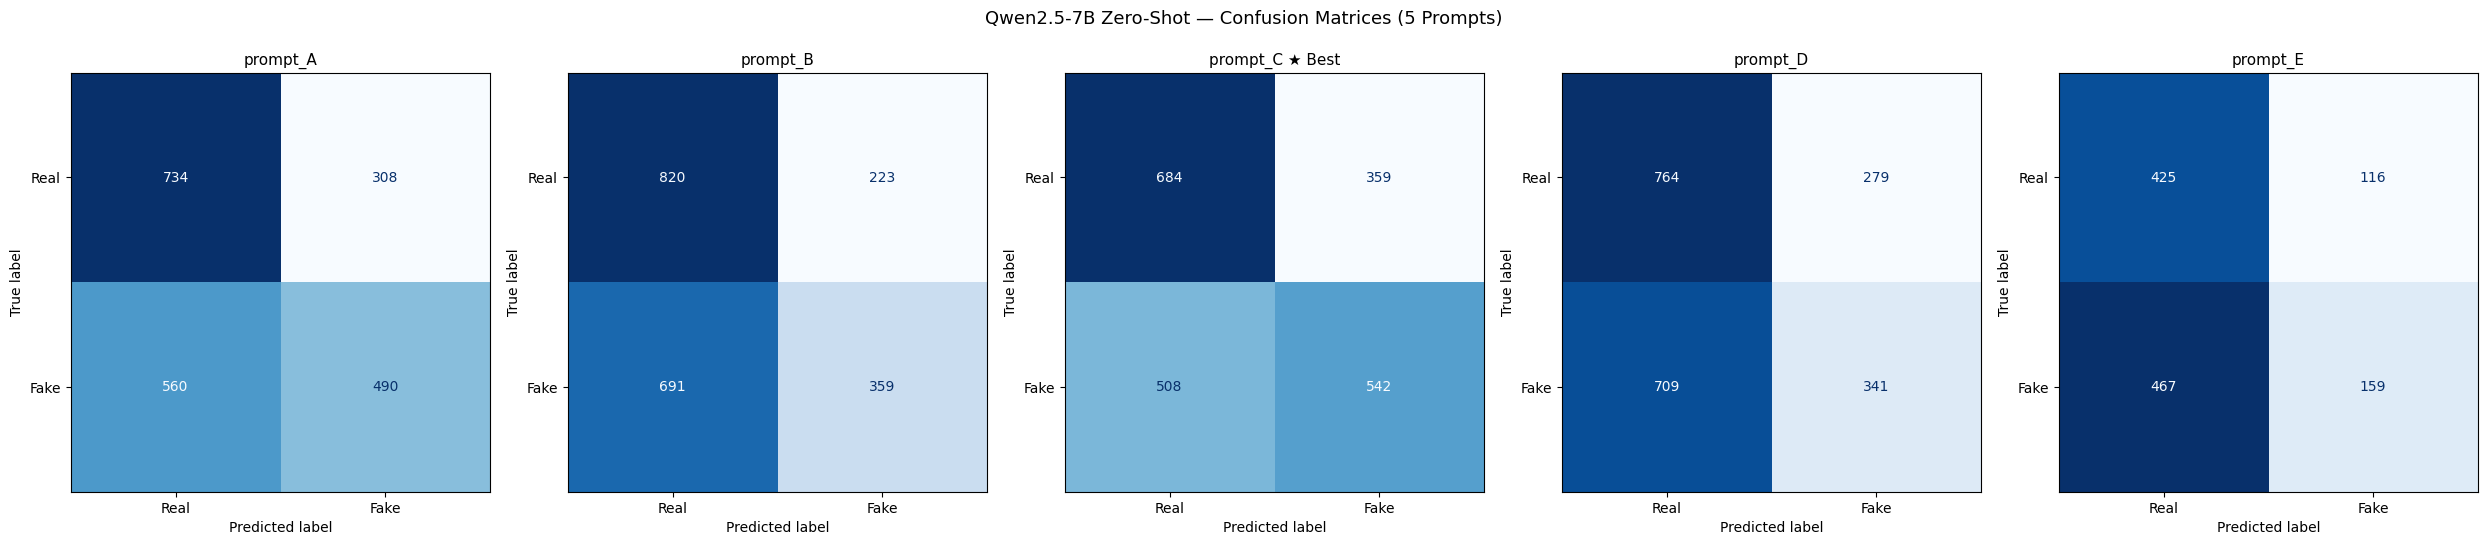

Saved: /content/qwen_confusion_matrices.png


In [ ]:
best_prompt = overall_df.loc[overall_df["f1"].idxmax(), "prompt"]
print(f"Best prompt by F1: {best_prompt}")

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, prompt_name in zip(axes, PROMPTS):
    pred_col = f"pred_{prompt_name}"
    valid = eval_df.dropna(subset=[pred_col]).copy()
    valid[pred_col] = valid[pred_col].astype(int)
    cm = confusion_matrix(valid["label"], valid[pred_col])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    title = prompt_name + (" ★ Best" if prompt_name == best_prompt else "")
    ax.set_title(title, fontsize=11)

plt.suptitle("Qwen2.5-7B Zero-Shot — Confusion Matrices (5 Prompts)", fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("/content/qwen_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: /content/qwen_confusion_matrices.png")

## 13. Recall by Length Group — Bar Chart

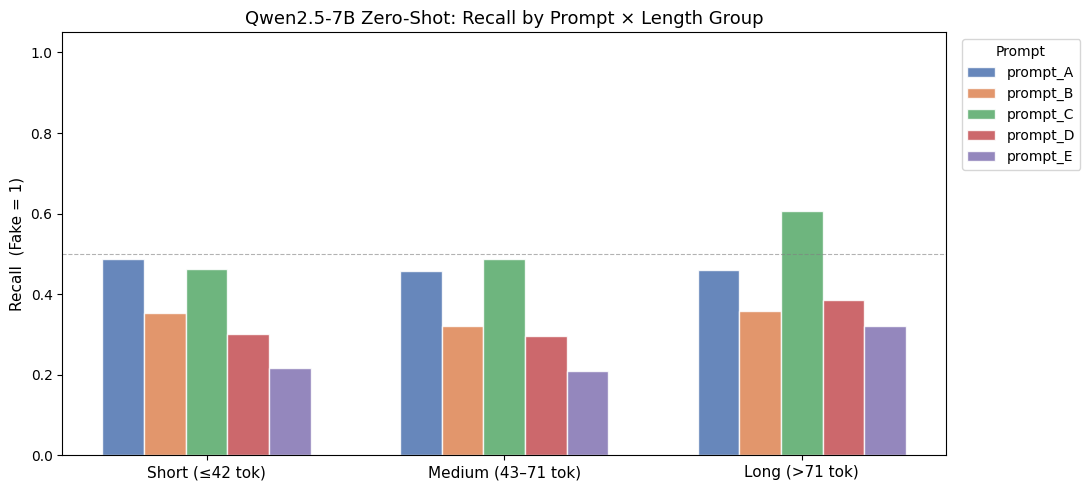

Saved: /content/qwen_recall_by_length.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
bar_w  = 0.14
x      = np.arange(3)
groups = ["short", "medium", "long"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

for idx, prompt_name in enumerate(PROMPTS):
    recalls = []
    for g in groups:
        row = group_df[(group_df["prompt"] == prompt_name) & (group_df["length_group"] == g)]
        recalls.append(row["recall"].values[0] if len(row) > 0 else 0.0)
    offset = (idx - 2) * bar_w
    ax.bar(x + offset, recalls, width=bar_w, label=prompt_name,
           color=colors[idx], alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(["Short (≤42 tok)", "Medium (43–71 tok)", "Long (>71 tok)"], fontsize=11)
ax.set_ylabel("Recall  (Fake = 1)", fontsize=11)
ax.set_title("Qwen2.5-7B Zero-Shot: Recall by Prompt × Length Group", fontsize=13)
ax.legend(title="Prompt", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6, label="chance")
plt.tight_layout()
plt.savefig("/content/qwen_recall_by_length.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: /content/qwen_recall_by_length.png")

## 14. Prompt Disagreement Analysis

In [ ]:
pred_cols = [f"pred_{p}" for p in PROMPTS]

# Keep only rows where ALL 5 prompts produced valid predictions
complete = eval_df.dropna(subset=pred_cols).copy()
for c in pred_cols:
    complete[c] = complete[c].astype(int)

# Disagreement = the 5 prompts do NOT all agree
complete["prompt_disagreement"] = complete[pred_cols].nunique(axis=1) > 1

overall_dis = complete["prompt_disagreement"].mean()
print(f"Overall prompt disagreement rate : {overall_dis:.3f}")

dis_by_len = complete.groupby("length_group")["prompt_disagreement"].mean()
print("\nDisagreement by length group:")
print(dis_by_len.to_string())

Overall prompt disagreement rate : 0.482

Disagreement by length group:
length_group
long      0.441006
medium    0.542857
short     0.473485


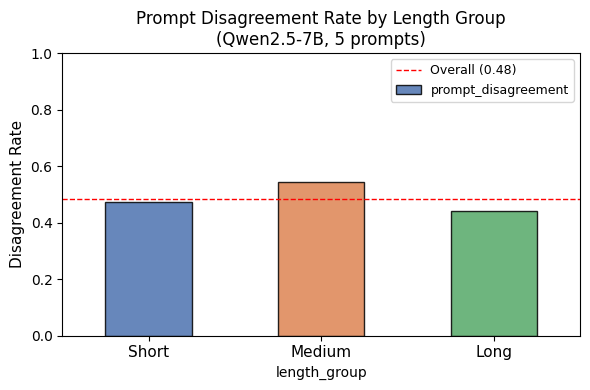

Saved: /content/qwen_disagreement_by_length.png


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
dis_by_len.reindex(["short", "medium", "long"]).plot(
    kind="bar", ax=ax,
    color=["#4C72B0", "#DD8452", "#55A868"],
    edgecolor="black", alpha=0.85
)
ax.set_xticklabels(["Short", "Medium", "Long"], rotation=0, fontsize=11)
ax.set_ylabel("Disagreement Rate", fontsize=11)
ax.set_title("Prompt Disagreement Rate by Length Group\n(Qwen2.5-7B, 5 prompts)", fontsize=12)
ax.set_ylim(0, 1)
ax.axhline(overall_dis, color="red", linestyle="--", linewidth=1,
           label=f"Overall ({overall_dis:.2f})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("/content/qwen_disagreement_by_length.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: /content/qwen_disagreement_by_length.png")

In [ ]:
print("Sample reviews where prompts disagree:")
display_cols = ["text", "label", "length_group"] + pred_cols
print(complete[complete["prompt_disagreement"]][display_cols].head(5).to_string())

Sample reviews where prompts disagree:
                                                                                                                                                                                                                                                                                                                                                     text  label length_group  pred_prompt_A  pred_prompt_B  pred_prompt_C  pred_prompt_D  pred_prompt_E
1   So bad experience. Got defected unit and they got the return and inspected the unit said it was not defected unit. I was very unhappy because they did not check it specifically. When I told them the symptom they said they do not have the item anymore. Also I had hard time to get refund for my extra shipping cost and original shipping cost.      1         long              0              0              0              1              0
8                                                                              

## 15. Save All Results

In [ ]:
# ── Save locally ─────────────────────────────────────────────────────────────
overall_df.to_csv("/content/qwen_overall_metrics.csv",    index=False)
group_df.to_csv("/content/qwen_group_metrics.csv",        index=False)
complete.to_csv("/content/qwen_all_predictions.csv",      index=False)
print("Results saved to /content/:")
print("  qwen_overall_metrics.csv")
print("  qwen_group_metrics.csv")
print("  qwen_all_predictions.csv")

Results saved to /content/:
  qwen_overall_metrics.csv
  qwen_group_metrics.csv
  qwen_all_predictions.csv


In [ ]:
# ── Optional: save to Google Drive ───────────────────────────────────────────
# Uncomment the block below to persist results across sessions.

# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE_DIR = "/content/drive/MyDrive/DATA6400_Qwen_ZeroShot"
# import os; os.makedirs(DRIVE_DIR, exist_ok=True)
# overall_df.to_csv(f"{DRIVE_DIR}/qwen_overall_metrics.csv",    index=False)
# group_df.to_csv(f"{DRIVE_DIR}/qwen_group_metrics.csv",        index=False)
# complete.to_csv(f"{DRIVE_DIR}/qwen_all_predictions.csv",      index=False)
# for fname in ["qwen_confusion_matrices.png", "qwen_recall_by_length.png",
#               "qwen_disagreement_by_length.png"]:
#     import shutil
#     shutil.copy(f"/content/{fname}", f"{DRIVE_DIR}/{fname}")
# print("Results saved to Google Drive.")

## 16. Final Summary

In [ ]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Model        : {QWEN_MODEL}")
print(f"Quantization : 4-bit NF4 (bitsandbytes)")
print(f"Test set     : {len(eval_df)} reviews")
print(f"Prompts      : {len(PROMPTS)}")
print()
print("Overall metrics:")
print(overall_df[["prompt","accuracy","precision","recall","f1"]].to_string(index=False))
print()
print("Best prompt by F1    :", overall_df.loc[overall_df["f1"].idxmax(),    "prompt"])
print("Best prompt by Recall:", overall_df.loc[overall_df["recall"].idxmax(), "prompt"])
print()
print("\u2713 Section complete. Copy the relevant cells into your main notebook.")


FINAL SUMMARY
Model        : Qwen/Qwen2.5-7B-Instruct
Quantization : 4-bit NF4 (bitsandbytes)
Test set     : 2098 reviews
Prompts      : 5

Overall metrics:
  prompt  accuracy  precision  recall     f1
prompt_A    0.5851     0.6140  0.4667 0.5303
prompt_B    0.5633     0.6168  0.3419 0.4400
prompt_C    0.5858     0.6016  0.5162 0.5556
prompt_D    0.5280     0.5500  0.3248 0.4084
prompt_E    0.5004     0.5782  0.2540 0.3529

Best prompt by F1    : prompt_C
Best prompt by Recall: prompt_C

✓ Section complete. Copy the relevant cells into your main notebook.
